In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import openpyxl

C:\Users\Hidou\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = r"C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\Fitness_clubs.xlsx"
df = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")
first_sheet = list(df.keys())[0]
data = df[first_sheet]
print("First 5 rows of the dataset:")
display(data.head())

First 5 rows of the dataset:


,club_id,club_name,services_offered,affiliated_players,certified_trainers,location,membership_fees,verified_status,contact_email,phone_number,created_at
0,CAF001,Wadi Degla Football Academy,"Youth training, scouting, fitness",150,12,Cairo Egypt,$500/year,Yes,info@wadidegla.com,+20 2 2529 0000,2009-06-15
1,CAF002,West African Football Academy,"Technical training, education, lodging",200,15,Accra Ghana,$400/year,Yes,admin@wafa-ghana.org,+233 30 396 7890,1999-01-20
2,CAF003,Pepsi Football Academy,"Grassroots training, talent development",300,20,Lagos Nigeria,$350/year,Yes,pepsiacademy@gmail.com,+234 1 454 1234,1992-11-10
3,CAF004,Diambars Institute,"Football education, scholarships",120,10,Saly Senegal,$600/year,Yes,contact@diambars.org,+221 33 957 1414,2003-03-25
4,CAF005,ASEC Mimosas Academy,"Elite training, competitive leagues",180,14,Abidjan Ivory Coast,$450/year,Yes,asecmimosas@asec.ci,+225 21 35 6789,1993-09-01


In [9]:
# Load the first sheet
first_sheet = list(df.keys())[0]  # Assuming we work with the first sheet
data = df[first_sheet]

# Display basic info
print("\nData Information:")
data.info()

# Display first few rows
print("\nFirst few rows of the data:")
print(data.head())



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   club_id             288 non-null    object        
 1   club_name           288 non-null    object        
 2   services_offered    288 non-null    object        
 3   affiliated_players  288 non-null    int64         
 4   certified_trainers  288 non-null    int64         
 5   location            288 non-null    object        
 6   membership_fees     288 non-null    object        
 7   verified_status     288 non-null    object        
 8   contact_email       288 non-null    object        
 9   phone_number        288 non-null    object        
 10  created_at          288 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 24.9+ KB

First few rows of the data:
  club_id                      club_name  \
0  CA

In [3]:
# Cell 2: Initial Data Overview
print("\nDataset Info:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())
print("\nSummary Statistics (Numerical):")
print(data.describe())
print("\nSummary Statistics (Categorical):")
print(data.describe(include=['object']))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   club_id             288 non-null    object        
 1   club_name           288 non-null    object        
 2   services_offered    288 non-null    object        
 3   affiliated_players  288 non-null    int64         
 4   certified_trainers  288 non-null    int64         
 5   location            288 non-null    object        
 6   membership_fees     288 non-null    object        
 7   verified_status     288 non-null    object        
 8   contact_email       288 non-null    object        
 9   phone_number        288 non-null    object        
 10  created_at          288 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 24.9+ KB

Missing Values:
club_id               0
club_name             0
services_offered 

In [4]:
# Cell 3: Data Cleaning
# Convert membership_fees to numeric
data['membership_fees'] = data['membership_fees'].str.replace('$', '').str.replace('/year', '').astype(float)
# Remove duplicates
data = data.drop_duplicates()
print("\nCleaned Data (First 5 rows):")
display(data.head())


Cleaned Data (First 5 rows):


,club_id,club_name,services_offered,affiliated_players,certified_trainers,location,membership_fees,verified_status,contact_email,phone_number,created_at
0,CAF001,Wadi Degla Football Academy,"Youth training, scouting, fitness",150,12,Cairo Egypt,500.0,Yes,info@wadidegla.com,+20 2 2529 0000,2009-06-15
1,CAF002,West African Football Academy,"Technical training, education, lodging",200,15,Accra Ghana,400.0,Yes,admin@wafa-ghana.org,+233 30 396 7890,1999-01-20
2,CAF003,Pepsi Football Academy,"Grassroots training, talent development",300,20,Lagos Nigeria,350.0,Yes,pepsiacademy@gmail.com,+234 1 454 1234,1992-11-10
3,CAF004,Diambars Institute,"Football education, scholarships",120,10,Saly Senegal,600.0,Yes,contact@diambars.org,+221 33 957 1414,2003-03-25
4,CAF005,ASEC Mimosas Academy,"Elite training, competitive leagues",180,14,Abidjan Ivory Coast,450.0,Yes,asecmimosas@asec.ci,+225 21 35 6789,1993-09-01


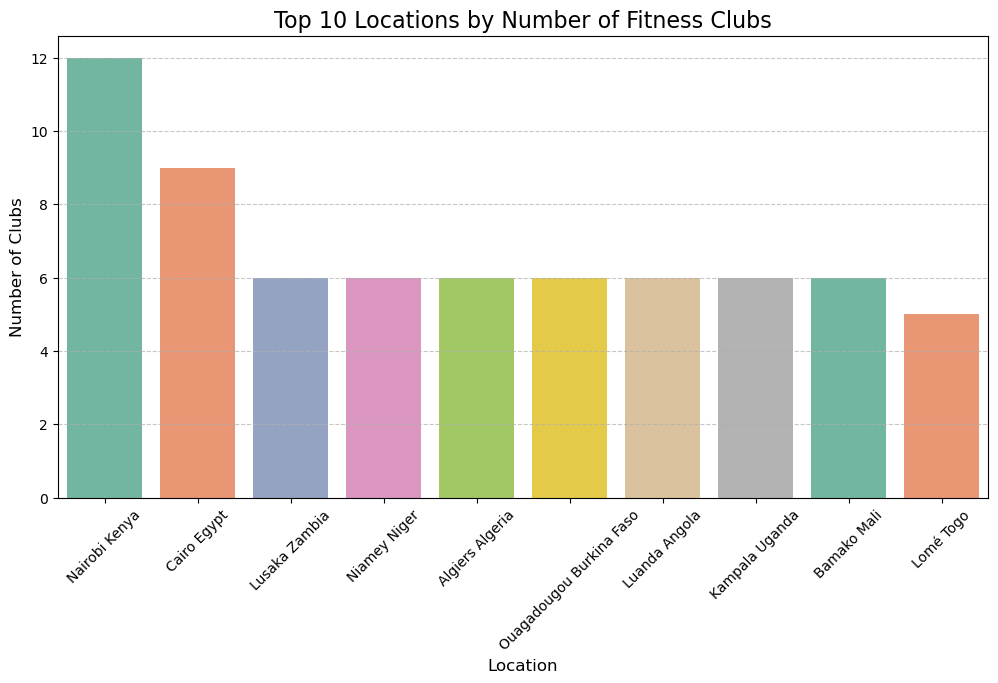

In [5]:
# Cell 4: Detailed EDA - Distribution of Clubs by Location
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='location', palette='Set2', order=data['location'].value_counts().index[:10])
plt.title('Top 10 Locations by Number of Fitness Clubs', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Clubs', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

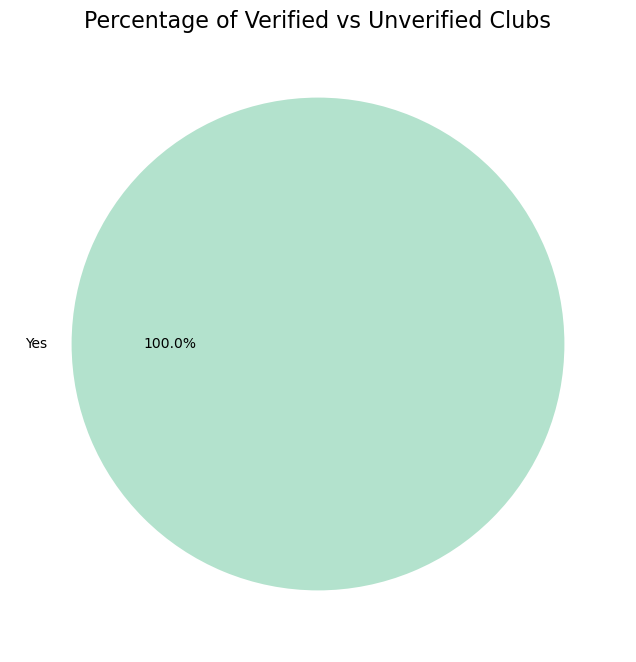

In [6]:
# Pie Chart for Verified Status
plt.figure(figsize=(8, 8))
data['verified_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Pastel2'))
plt.title('Percentage of Verified vs Unverified Clubs', fontsize=16)
plt.ylabel('')
plt.show()

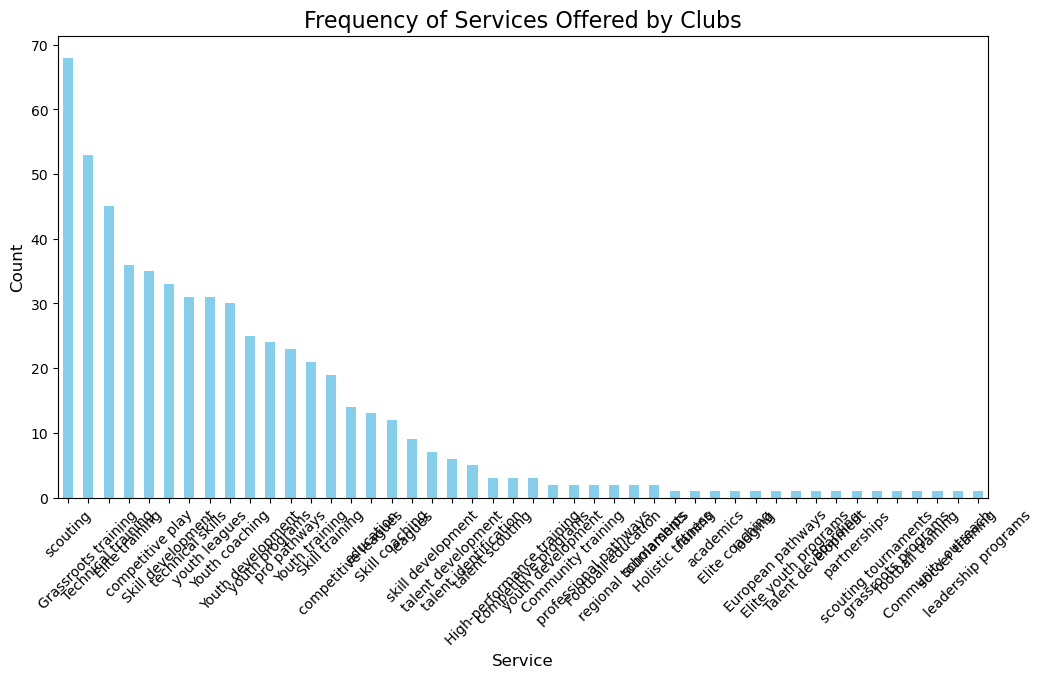

In [7]:
# Cell 5: Services Offered Analysis
# Split services_offered into individual services
services = data['services_offered'].str.split(', ', expand=True).stack().value_counts()
plt.figure(figsize=(12, 6))
services.plot(kind='bar', color='skyblue')
plt.title('Frequency of Services Offered by Clubs', fontsize=16)
plt.xlabel('Service', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

TypeError: xticks(): Parameter 'labels' can't be set without setting 'ticks'

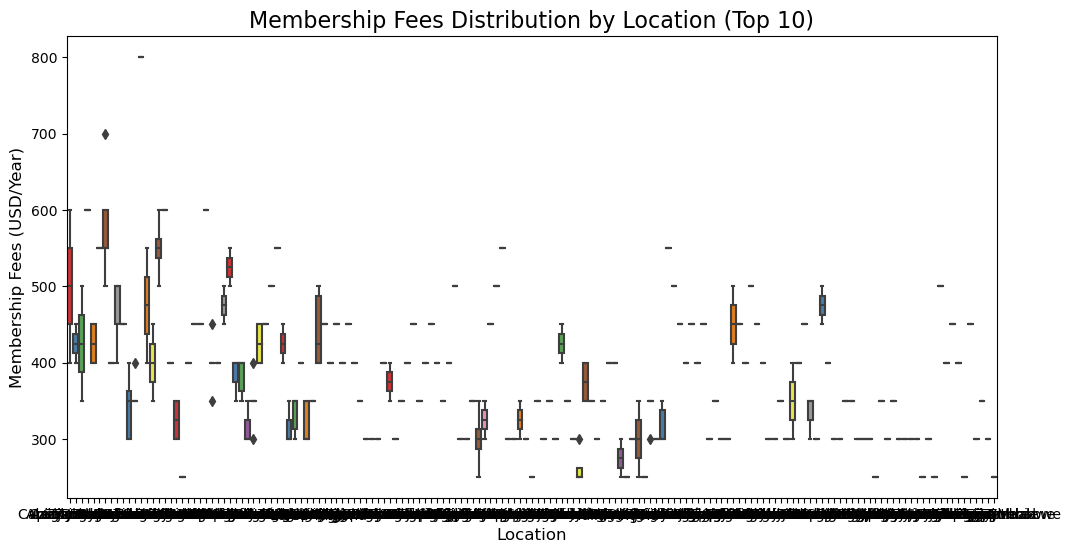

In [8]:
# Cell 6: Numerical Features Analysis
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='membership_fees', data=data, palette='Set1')
plt.title('Membership Fees Distribution by Location (Top 10)', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Membership Fees (USD/Year)', fontsize=12)
plt.xticks(rotation=45, labels=data['location'].value_counts().index[:10])
plt.show()

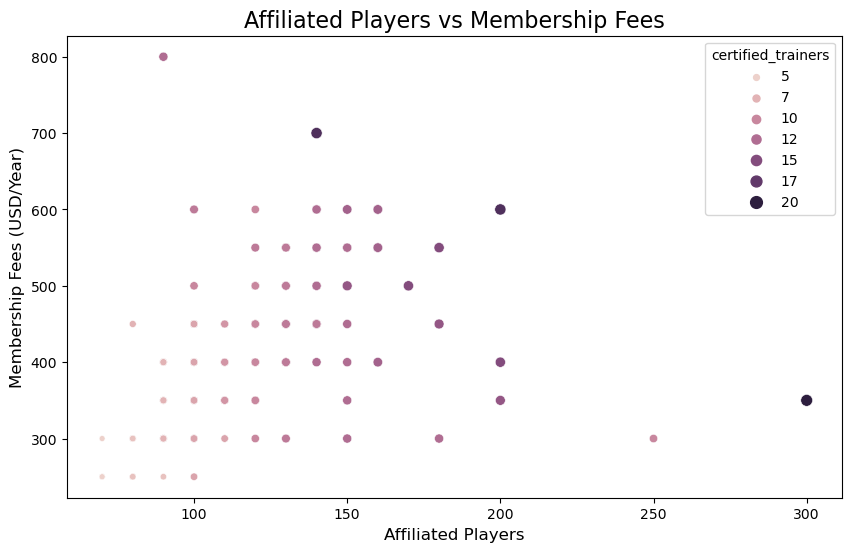

In [9]:
# Scatter Plot: Affiliated Players vs Membership Fees
plt.figure(figsize=(10, 6))
sns.scatterplot(x='affiliated_players', y='membership_fees', hue='certified_trainers', size='certified_trainers', data=data)
plt.title('Affiliated Players vs Membership Fees', fontsize=16)
plt.xlabel('Affiliated Players', fontsize=12)
plt.ylabel('Membership Fees (USD/Year)', fontsize=12)
plt.show()

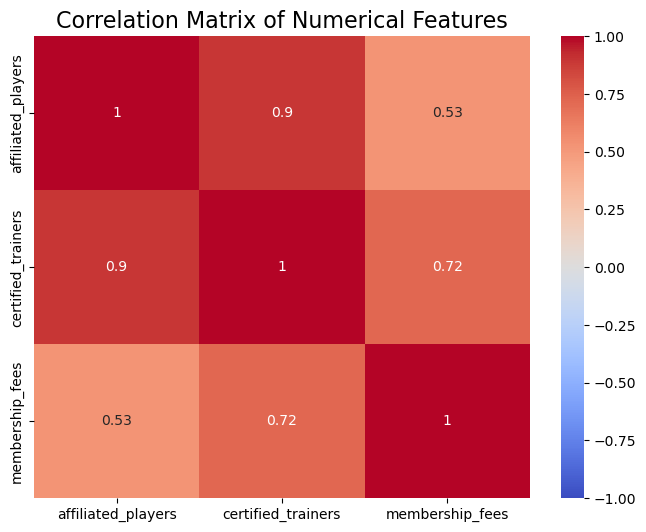

In [10]:
# Cell 7: Correlation Analysis
numerical_cols = ['affiliated_players', 'certified_trainers', 'membership_fees']
corr_matrix = data[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

In [11]:
# Cell 8: Feature Encoding for Modeling
le = LabelEncoder()
data_encoded = data.copy()
for col in ['services_offered', 'location', 'verified_status']:
    data_encoded[col] = le.fit_transform(data_encoded[col])

# Standardize numerical features
scaler = StandardScaler()
numerical_features = ['affiliated_players', 'certified_trainers', 'membership_fees']
data_encoded[numerical_features] = scaler.fit_transform(data_encoded[numerical_features])


Linear Regression Results:
R^2 Score: 0.6769
Mean Squared Error: 0.3760
Coefficients: {'affiliated_players': -0.6930295372749595, 'certified_trainers': 1.3398143366653124, 'location': 0.0025569893067328583, 'services_offered': 0.001317882955549908}


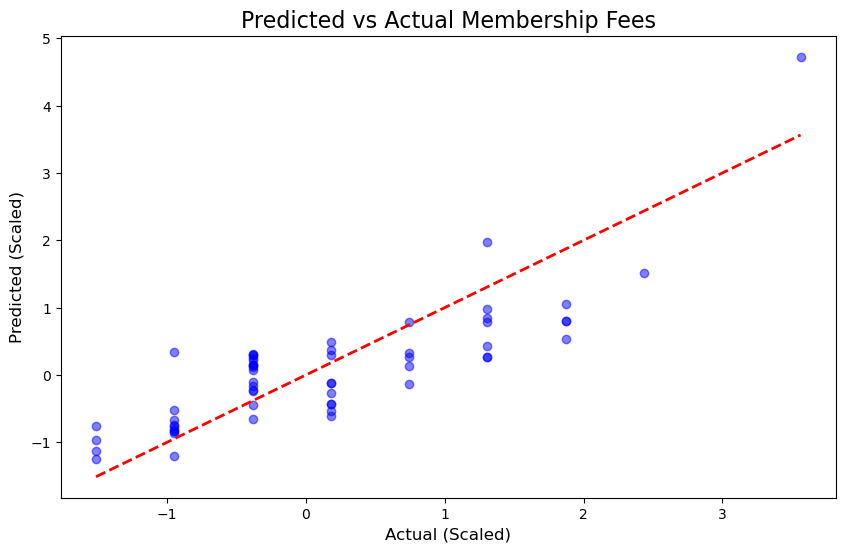

In [14]:

X = data_encoded[['affiliated_players', 'certified_trainers', 'location', 'services_offered']]
y = data_encoded['membership_fees']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nLinear Regression Results:")
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print("Coefficients:", dict(zip(X.columns, model.coef_)))
# Plot Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicted vs Actual Membership Fees', fontsize=16)
plt.xlabel('Actual (Scaled)', fontsize=12)
plt.ylabel('Predicted (Scaled)', fontsize=12)
plt.show()

In [15]:
# Cell 10: Save Enhanced Data
data.to_csv(r'C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\enhanced_fitness_clubs.csv', index=False)
print("Enhanced data saved.")

Enhanced data saved.
